
--- Monte Carlo ---
99% VaR: $23,801
99% CVaR: $27,786


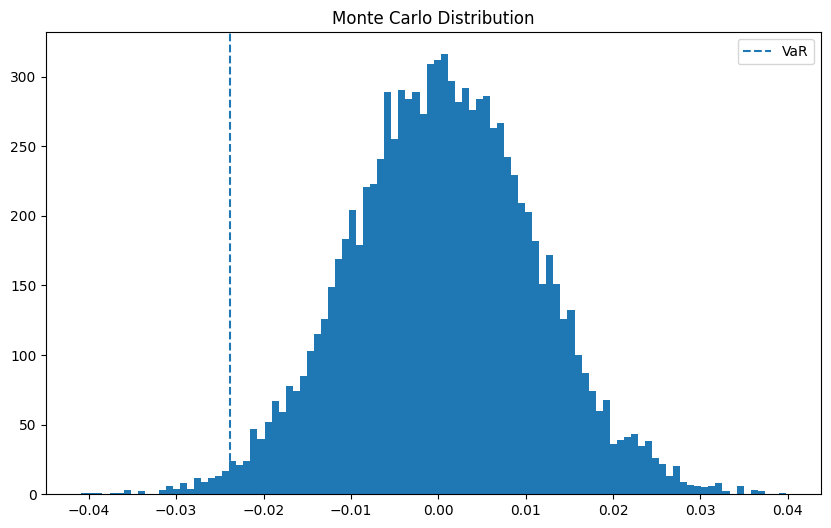

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load
log_returns = pd.read_csv("../data/log_returns.csv", index_col=0, parse_dates=True)
portfolio_returns = pd.read_csv("../data/portfolio_returns.csv", index_col=0, parse_dates=True)

# Setup
n_assets = log_returns.shape[1]
weights = np.array([1/n_assets]*n_assets)

# Covariance
cov_matrix = log_returns.cov()

# Cholesky
L = np.linalg.cholesky(cov_matrix)

# Simulate
num_simulations = 10000

random_normals = np.random.standard_normal((num_simulations, n_assets))
simulated_returns = random_normals @ L.T

# Add mean
mean_returns = log_returns.mean().values
simulated_returns += mean_returns

# Portfolio simulation
sim_portfolio_returns = simulated_returns @ weights

# VaR
mc_var_99 = np.percentile(sim_portfolio_returns, 1)
mc_cvar_99 = sim_portfolio_returns[sim_portfolio_returns <= mc_var_99].mean()

print("\n--- Monte Carlo ---")
print(f"99% VaR: ${abs(mc_var_99)*1_000_000:,.0f}")
print(f"99% CVaR: ${abs(mc_cvar_99)*1_000_000:,.0f}")

# Plot
plt.figure(figsize=(10,6))
plt.hist(sim_portfolio_returns, bins=100)

plt.axvline(mc_var_99, linestyle='--', label='VaR')

plt.legend()
plt.title("Monte Carlo Distribution")
plt.show()